In [21]:
import pandas as pd
import numpy as np

train_path = "../data/aps_failure_training_set.csv"
test_path = "../data/aps_failure_test_set.csv"

In [22]:
def find_header_row(filepath):
    with open(filepath, 'r') as f:
        for i, line in enumerate(f):
            if line.startswith("class,"):
                return i
    raise ValueError("Header row starting with 'class,' not found")

train_skip = find_header_row(train_path)
test_skip = find_header_row(test_path)
print(f"Training file: skip {train_skip} rows before header")
print(f"Test file: skip {test_skip} rows before header")

Training file: skip 20 rows before header
Test file: skip 20 rows before header


In [23]:
df_train = pd.read_csv(train_path, skiprows=train_skip, na_values='na')
df_test = pd.read_csv(test_path, skiprows=test_skip, na_values='na')

print("Train shape:", df_train.shape)
print("Test shape:", df_test.shape)
print(df_train['class'].value_counts())

Train shape: (60000, 171)
Test shape: (16000, 171)
class
neg    59000
pos     1000
Name: count, dtype: int64


In [24]:
missing_pct = (df_train.isnull().sum() / len(df_train) * 100).sort_values(ascending=False)
print(missing_pct.head(20))
print("\nColumns with >70% missing:", (missing_pct > 70).sum())
print("Columns with 0% missing:", (missing_pct == 0).sum())

br_000    82.106667
bq_000    81.203333
bp_000    79.566667
bo_000    77.221667
ab_000    77.215000
cr_000    77.215000
bn_000    73.348333
bm_000    65.915000
bl_000    45.461667
bk_000    38.390000
ad_000    24.768333
cg_000    24.768333
ch_000    24.768333
cf_000    24.768333
co_000    24.768333
cx_000    23.013333
cz_000    23.013333
cy_000    23.013333
dc_000    23.013333
db_000    23.013333
dtype: float64

Columns with >70% missing: 7
Columns with 0% missing: 2


In [25]:
import re

# Group columns by their prefix (e.g., ag_000, ag_001, ag_002 -> prefix 'ag')
col_groups = {}
for col in df_train.columns:
    if col == 'class':
        continue
    match = re.match(r'^([a-z]+)_(\d+)$', col)
    if match:
        prefix, bin_num = match.groups()
        col_groups.setdefault(prefix, []).append(col)

# Histogram variables have multiple bin columns under one prefix
histogram_groups = {k: v for k, v in col_groups.items() if len(v) > 1}
single_counters = {k: v for k, v in col_groups.items() if len(v) == 1}

print(f"Histogram-style groups found: {len(histogram_groups)}")
for prefix, cols in histogram_groups.items():
    print(f"  {prefix}: {cols}")
print(f"\nSingle-value counters: {len(single_counters)}")

Histogram-style groups found: 7
  ag: ['ag_000', 'ag_001', 'ag_002', 'ag_003', 'ag_004', 'ag_005', 'ag_006', 'ag_007', 'ag_008', 'ag_009']
  ay: ['ay_000', 'ay_001', 'ay_002', 'ay_003', 'ay_004', 'ay_005', 'ay_006', 'ay_007', 'ay_008', 'ay_009']
  az: ['az_000', 'az_001', 'az_002', 'az_003', 'az_004', 'az_005', 'az_006', 'az_007', 'az_008', 'az_009']
  ba: ['ba_000', 'ba_001', 'ba_002', 'ba_003', 'ba_004', 'ba_005', 'ba_006', 'ba_007', 'ba_008', 'ba_009']
  cn: ['cn_000', 'cn_001', 'cn_002', 'cn_003', 'cn_004', 'cn_005', 'cn_006', 'cn_007', 'cn_008', 'cn_009']
  cs: ['cs_000', 'cs_001', 'cs_002', 'cs_003', 'cs_004', 'cs_005', 'cs_006', 'cs_007', 'cs_008', 'cs_009']
  ee: ['ee_000', 'ee_001', 'ee_002', 'ee_003', 'ee_004', 'ee_005', 'ee_006', 'ee_007', 'ee_008', 'ee_009']

Single-value counters: 100


In [26]:
cols_to_drop = ['br_000', 'bq_000', 'bp_000', 'bo_000', 'ab_000', 'cr_000', 'bn_000']

df_train_clean = df_train.drop(columns=cols_to_drop)
df_test_clean = df_test.drop(columns=cols_to_drop)

print("Train shape after drop:", df_train_clean.shape)
print("Test shape after drop:", df_test_clean.shape)

Train shape after drop: (60000, 164)
Test shape after drop: (16000, 164)


Comparative analysis

In [27]:
from sklearn.model_selection import train_test_split

df_train_clean['label'] = (df_train_clean['class'] == 'pos').astype(int)

X = df_train_clean.drop(columns=['class', 'label'])
y = df_train_clean['label']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Train:", X_train.shape, "Positives:", y_train.sum())
print("Val:", X_val.shape, "Positives:", y_val.sum())

C:\Users\HP\AppData\Local\Temp\ipykernel_285364\1679632036.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_train_clean['label'] = (df_train_clean['class'] == 'pos').astype(int)


Train: (48000, 163) Positives: 800
Val: (12000, 163) Positives: 200


In [28]:
def total_cost(y_true, y_pred):
    fp = ((y_pred == 1) & (y_true == 0)).sum()  # false positive: unnecessary check
    fn = ((y_pred == 0) & (y_true == 1)).sum()  # false negative: missed failure
    return fp * 10 + fn * 500

In [29]:
import xgboost as xgb

model_a = xgb.XGBClassifier(
    scale_pos_weight=(y_train==0).sum() / (y_train==1).sum(),
    eval_metric='logloss',
    random_state=42
)
model_a.fit(X_train, y_train)

pred_a = model_a.predict(X_val)
cost_a = total_cost(y_val, pred_a)
print("Variant A (7 dropped) cost:", cost_a)

Variant A (7 dropped) cost: 14430


In [30]:
mid_tier_cols = ['bl_000', 'bk_000', 'bm_000']

X_train_b = X_train.drop(columns=mid_tier_cols)
X_val_b = X_val.drop(columns=mid_tier_cols)

model_b = xgb.XGBClassifier(
    scale_pos_weight=(y_train==0).sum() / (y_train==1).sum(),
    eval_metric='logloss',
    random_state=42
)
model_b.fit(X_train_b, y_train)

pred_b = model_b.predict(X_val_b)
cost_b = total_cost(y_val, pred_b)
print("Variant B (7 + mid-tier dropped) cost:", cost_b)

Variant B (7 + mid-tier dropped) cost: 16950


Dividing negative class into 6 subsets

In [31]:
import numpy as np

# Separating positives (A) and negatives (B) from your training split
train_pos = X_train[y_train == 1]
train_neg = X_train[y_train == 0]

y_train_pos = y_train[y_train == 1]
y_train_neg = y_train[y_train == 0]

print("Positives (A):", train_pos.shape[0])
print("Negatives (B) total:", train_neg.shape[0])

# Shuffle negative indices once then split into 6 roughly equal non-overlapping chunks
np.random.seed(42)
shuffled_idx = np.random.permutation(train_neg.index)
neg_splits = np.array_split(shuffled_idx, 6)

for i, split in enumerate(neg_splits):
    print(f"Subset B{i+1}: {len(split)} negative examples")

Positives (A): 800
Negatives (B) total: 47200
Subset B1: 7867 negative examples
Subset B2: 7867 negative examples
Subset B3: 7867 negative examples
Subset B4: 7867 negative examples
Subset B5: 7866 negative examples
Subset B6: 7866 negative examples


In [32]:
models = []

for i, neg_idx in enumerate(neg_splits):
    # Combine full positive set with this negative subset
    X_subset = pd.concat([train_pos, train_neg.loc[neg_idx]])
    y_subset = pd.concat([y_train_pos, y_train_neg.loc[neg_idx]])

    model = xgb.XGBClassifier(
        eval_metric='logloss',
        random_state=42 + i
    )
    model.fit(X_subset, y_subset)
    models.append(model)
    print(f"Model {i+1} trained on {X_subset.shape[0]} rows "
          f"({y_subset.sum()} pos / {(y_subset==0).sum()} neg)")

print(f"\nTotal models trained: {len(models)}")

Model 1 trained on 8667 rows (800 pos / 7867 neg)
Model 2 trained on 8667 rows (800 pos / 7867 neg)
Model 3 trained on 8667 rows (800 pos / 7867 neg)
Model 4 trained on 8667 rows (800 pos / 7867 neg)
Model 5 trained on 8666 rows (800 pos / 7866 neg)
Model 6 trained on 8666 rows (800 pos / 7866 neg)

Total models trained: 6


In [33]:
# Get probability of positive class from each of the 6 models
val_probs = np.column_stack([model.predict_proba(X_val)[:, 1] for model in models])

print("Shape (rows, models):", val_probs.shape)

# Average across the 6 models — this is your combined ensemble score
val_probs_avg = val_probs.mean(axis=1)

print("Sample averaged probabilities:", val_probs_avg[:5])

Shape (rows, models): (12000, 6)
Sample averaged probabilities: [3.1394451e-05 2.8685201e-04 1.8917317e-05 1.5585854e-05 9.1070849e-01]


In [34]:
thresholds = np.arange(0.01, 1.00, 0.01)
results = []

for t in thresholds:
    preds = (val_probs_avg >= t).astype(int)
    cost = total_cost(y_val.values, preds)
    results.append((t, cost))

results_df = pd.DataFrame(results, columns=['threshold', 'cost'])
best_row = results_df.loc[results_df['cost'].idxmin()]

print("Best threshold:", best_row['threshold'])
print("Minimum cost:", best_row['cost'])
print("\nCost at default 0.5 threshold:", 
      results_df.loc[results_df['threshold'] == 0.50, 'cost'].values[0])

Best threshold: 0.05
Minimum cost: 5520.0

Cost at default 0.5 threshold: 9270


threshold-sweeping the single model too for a fair comparison

In [35]:
single_probs = model_a.predict_proba(X_val)[:, 1]

single_results = []
for t in thresholds:
    preds = (single_probs >= t).astype(int)
    cost = total_cost(y_val.values, preds)
    single_results.append((t, cost))

single_results_df = pd.DataFrame(single_results, columns=['threshold', 'cost'])
best_single = single_results_df.loc[single_results_df['cost'].idxmin()]

print("Single model best threshold:", best_single['threshold'])
print("Single model minimum cost:", best_single['cost'])
results_df.to_csv("../outputs/threshold_sweep_single_model.csv", index=False)

Single model best threshold: 0.01
Single model minimum cost: 5530.0


C:\Users\HP\AppData\Local\Temp\ipykernel_285364\1945689115.py:7: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_val, plot_type="bar", show=False)


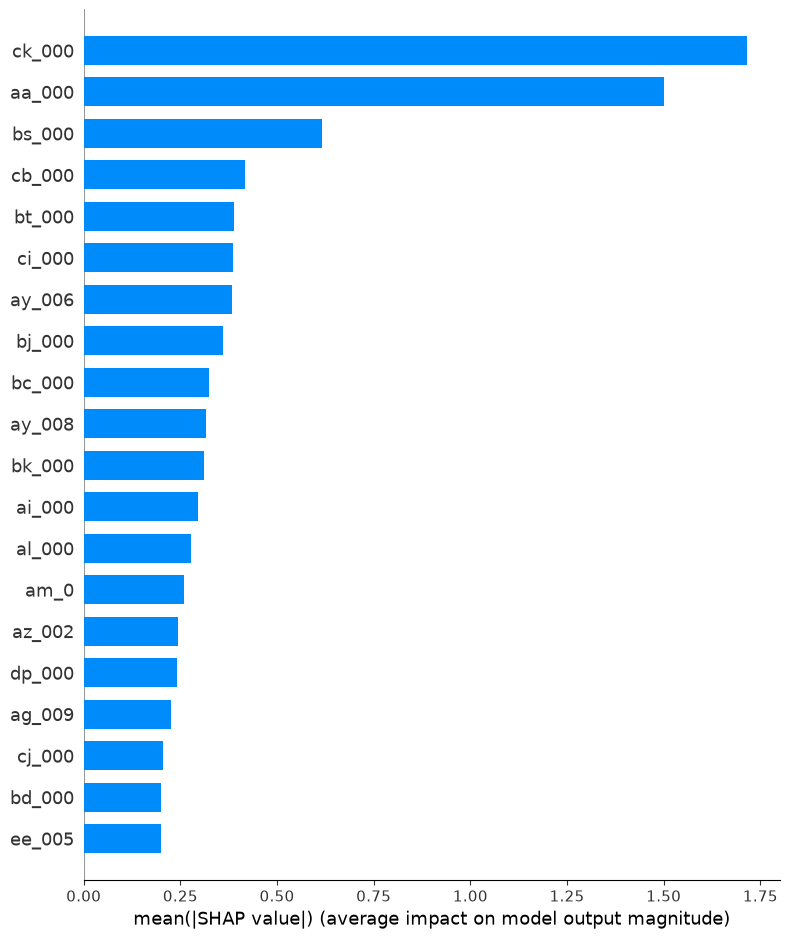

In [47]:
import shap
import matplotlib.pyplot as plt
explainer = shap.TreeExplainer(model_a)
shap_values = explainer.shap_values(X_val)

# Global importance — mean absolute SHAP value per feature
shap.summary_plot(shap_values, X_val, plot_type="bar", show=False)
fig = plt.gcf()
fig.savefig("../outputs/shap_global_importance.png", bbox_inches='tight', dpi=150)
plt.show()

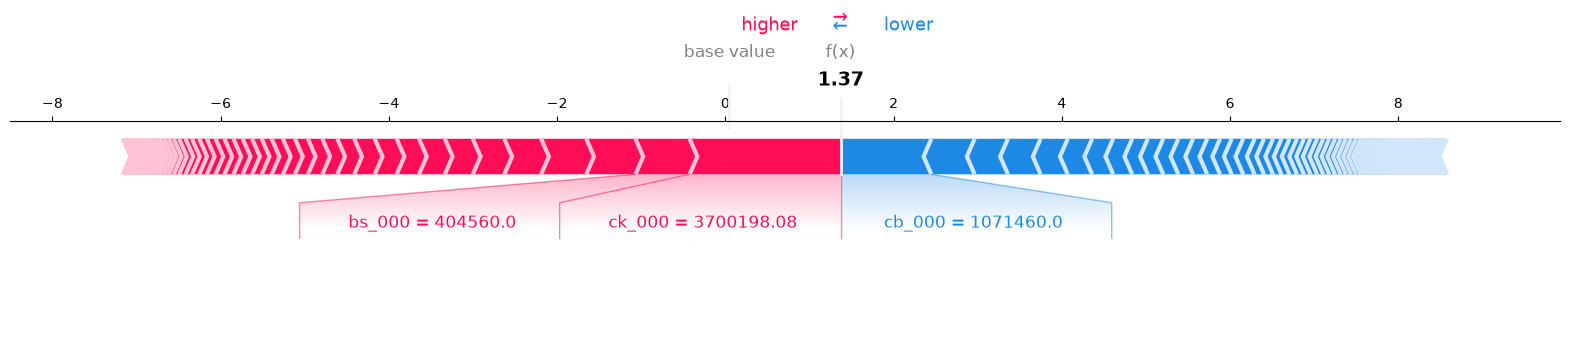

In [49]:
# Find a truck the model flagged as high-risk (using your tuned threshold, 0.01)
high_risk_idx = np.where(single_probs >= 0.01)[0][0]  # first flagged truck

shap.force_plot(
    explainer.expected_value,
    shap_values[high_risk_idx],
    X_val.iloc[high_risk_idx],
    matplotlib=True,
    show=False
)
plt.savefig("../outputs/shap_local_explanation_truck.png", bbox_inches='tight', dpi=150)
plt.show()

In [38]:
explainer_proba = shap.TreeExplainer(model_a, model_output="probability", data=X_train)

Background dataset has 48000 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=48000 when initializing the masker.


In [39]:
explainer_proba = shap.TreeExplainer(model_a, model_output="probability", data=shap.sample(X_train, 1000))

Background dataset has 1000 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=1000 when initializing the masker.


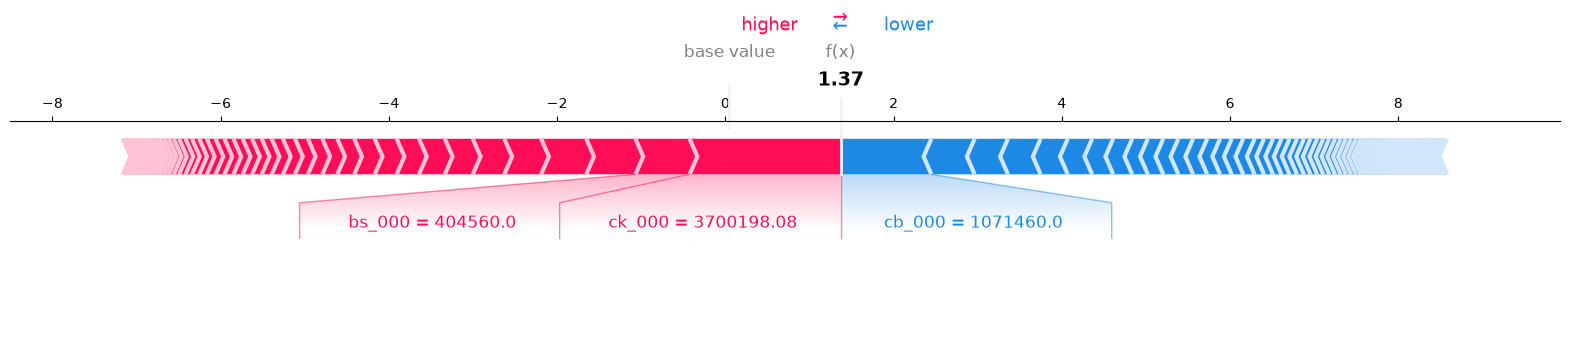

In [40]:
explainer = shap.TreeExplainer(model_a)
shap_values = explainer(X_val)

shap.force_plot(
    explainer.expected_value,
    shap_values.values[high_risk_idx],
    X_val.iloc[high_risk_idx],
    matplotlib=True,
    show=True
)

In [41]:
# Prepare test set the same way as training data
df_test_clean['label'] = (df_test_clean['class'] == 'pos').astype(int)
X_test = df_test_clean.drop(columns=['class', 'label'])
y_test = df_test_clean['label']

# Use your single tuned model (threshold 0.01, from earlier)
test_probs = model_a.predict_proba(X_test)[:, 1]
test_preds = (test_probs >= 0.01).astype(int)

test_cost = total_cost(y_test.values, test_preds)
print("Final test set cost:", test_cost)

print("\nFor reference 2016 challenge leaderboard:")
print("1st place: 9920")
print("2nd place: 10900")
print("3rd place: 11480")

Final test set cost: 13830

For reference 2016 challenge leaderboard:
1st place: 9920
2nd place: 10900
3rd place: 11480


C:\Users\HP\AppData\Local\Temp\ipykernel_285364\666026874.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_test_clean['label'] = (df_test_clean['class'] == 'pos').astype(int)


Using cross validation

In [42]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_threshold_costs = {t: [] for t in np.arange(0.01, 1.00, 0.01)}

for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_tr, X_v = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_v = y.iloc[train_idx], y.iloc[val_idx]

    fold_model = xgb.XGBClassifier(
        scale_pos_weight=(y_tr==0).sum() / (y_tr==1).sum(),
        eval_metric='logloss',
        random_state=42
    )
    fold_model.fit(X_tr, y_tr)
    fold_probs = fold_model.predict_proba(X_v)[:, 1]

    for t in fold_threshold_costs.keys():
        preds = (fold_probs >= t).astype(int)
        cost = total_cost(y_v.values, preds)
        fold_threshold_costs[t].append(cost)

    print(f"Fold {fold_idx+1} done")

# Average cost per threshold across all 5 folds
avg_costs = {t: np.mean(costs) for t, costs in fold_threshold_costs.items()}
best_t = min(avg_costs, key=avg_costs.get)
print(f"\nBest threshold (avg across folds): {best_t}")
print(f"Average cost at this threshold: {avg_costs[best_t]}")
avg_costs_df = pd.DataFrame(list(avg_costs.items()), columns=['threshold', 'avg_cost'])
avg_costs_df.to_csv("../outputs/threshold_sweep_cv.csv", index=False)

Fold 1 done
Fold 2 done
Fold 3 done
Fold 4 done
Fold 5 done

Best threshold (avg across folds): 0.01
Average cost at this threshold: 9222.0


In [43]:
final_model = xgb.XGBClassifier(
    scale_pos_weight=(y==0).sum() / (y==1).sum(),
    eval_metric='logloss',
    random_state=42
)
final_model.fit(X, y)  # train on ALL 60,000 rows, not just 80%

final_test_probs = final_model.predict_proba(X_test)[:, 1]
final_test_preds = (final_test_probs >= 0.01).astype(int)

final_test_cost = total_cost(y_test.values, final_test_preds)
print("Final test cost (full training data, CV-validated threshold):", final_test_cost)

print("\n2016 leaderboard for reference:")
print("1st: 9920 | 2nd: 10900 | 3rd: 11480")
final_model.save_model("../outputs/final_xgb_model.json")

Final test cost (full training data, CV-validated threshold): 14920

2016 leaderboard for reference:
1st: 9920 | 2nd: 10900 | 3rd: 11480


In [44]:
print("Train positive rate:", y.mean())
print("Test positive rate:", y_test.mean())
print("Train positive count:", y.sum(), "/ Train total:", len(y))
print("Test positive count:", y_test.sum(), "/ Test total:", len(y_test))

Train positive rate: 0.016666666666666666
Test positive rate: 0.0234375
Train positive count: 1000 / Train total: 60000
Test positive count: 375 / Test total: 16000


In [45]:
for col in ['ck_000', 'aa_000', 'bs_000']:
    print(f"\n{col}:")
    print("  Train mean:", X[col].mean(), "| Train median:", X[col].median())
    print("  Test mean:", X_test[col].mean(), "| Test median:", X_test[col].median())


ck_000:
  Train mean: 714342.701851765 | Train median: 250267.2
  Test mean: 757855.8535804951 | Test median: 256016.64

aa_000:
  Train mean: 59336.499566666665 | Train median: 30776.0
  Test mean: 67996.98375 | Test median: 30982.0

bs_000:
  Train mean: 80360.54931335831 | Train median: 50540.0
  Test mean: 81667.88580833017 | Test median: 52240.0


In [46]:
summary = {
    "validation_cost_default_threshold": 9270,
    "validation_cost_tuned_threshold": 5530,
    "best_threshold": 0.01,
    "ensemble_validation_cost": 5520,
    "single_model_validation_cost": 5530,
    "final_test_cost": 14920,
    "test_positive_rate": float(y_test.mean()),
    "train_positive_rate": float(y.mean()),
    "leaderboard_1st": 9920,
    "leaderboard_2nd": 10900,
    "leaderboard_3rd": 11480
}

import json
with open("../outputs/results_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print("Saved results summary.")

Saved results summary.
